# Redes neurais com PyTorch

Tres arquiteturas, do mais simples ao mais estruturado:

1. **MLP** (perceptron multicamadas) em dados tabulares: classificacao de vinhos.
2. **CNN** (rede convolucional) no MNIST: classificar digitos a partir dos pixels.
3. **Autoencoder** no MNIST: comprimir e reconstruir as imagens sem usar os rotulos.

A ideia comum: empilhar camadas que transformam a entrada, e ajustar os pesos por
descida de gradiente minimizando uma funcao de perda. O PyTorch cuida das derivadas
(autograd) e do passo de otimizacao.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

torch.manual_seed(0)
np.random.seed(0)

# usa GPU se houver, senao CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

## 1. MLP em dados tabulares

Um MLP e uma sequencia de camadas lineares (`Linear`) intercaladas com uma nao
linearidade (`ReLU`). Cada `Linear` faz `x @ W + b`; sem a ReLU no meio, varias
camadas colapsariam em uma so transformacao linear.

Usamos o dataset `wine` do scikit-learn: 13 medidas quimicas para prever uma de 3
castas. Como os atributos tem escalas bem diferentes, padronizamos (media 0, desvio 1)
antes de entrar na rede.

In [3]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

dados = load_wine()
X, y = dados.data, dados.target
print('formato', X.shape, '| classes', np.unique(y))

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)

escala = StandardScaler().fit(X_tr)
X_tr = escala.transform(X_tr)
X_te = escala.transform(X_te)

# tensores do PyTorch: float para os atributos, long para os rotulos
X_tr = torch.tensor(X_tr, dtype=torch.float32)
X_te = torch.tensor(X_te, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)
y_te = torch.tensor(y_te, dtype=torch.long)

formato (178, 13) | classes [0 1 2]


A rede recebe 13 entradas e devolve 3 numeros (um *score* por classe, os *logits*).
O `nn.Sequential` empilha as camadas na ordem dada. As duas camadas que aparecem aqui:

**`nn.Linear(13, 32)`** — camada densa, faz `x @ W + b`.
- `13`: numero de entradas (cada neuronio enxerga as 13 entradas).
- `32`: numero de saidas (quantos neuronios a camada tem).
- Os pesos `W` (forma `13 x 32`) e o vies `b` sao o que a rede aprende.

**`nn.ReLU()`** — funcao de ativacao, sem pesos nem argumentos. Aplica `max(0, x)`
ponto a ponto: zera os negativos e mantem os positivos. E ela que da nao linearidade
a rede; sem uma ativacao entre as `Linear`, varias camadas colapsariam em uma so.


In [4]:
mlp = nn.Sequential(
    nn.Linear(13, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 3),
)
mlp

Sequential(
  (0): Linear(in_features=13, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=3, bias=True)
)

### O laco de treino e uma receita de bolo

Treinar uma rede e sempre a mesma receita, sem importar a arquitetura. Decore esses
passos: eles se repetem identicos no MLP, na CNN e no autoencoder. So mudam o modelo,
a funcao de perda e os dados.

Antes do laco, dois ingredientes:

- **`otim = torch.optim.Adam(mlp.parameters(), lr=1e-2)`** — o otimizador. Recebe os
  pesos da rede (`mlp.parameters()`) e e quem os ajusta. `lr` e a taxa de aprendizado,
  o tamanho do passo a cada atualizacao.
- **`perda_fn = nn.CrossEntropyLoss()`** — a funcao de perda, mede o quanto a rede
  errou. Para classificacao usamos a entropia cruzada (ela ja aplica o softmax
  internamente, entao passamos os *logits* direto).

E o laco, repetido a cada `epoca` (uma passada pelos dados). Sempre os mesmos 4 passos:

1. **`otim.zero_grad()`** — zera os gradientes acumulados do passo anterior (o PyTorch
   soma gradientes por padrao, entao precisamos limpar).
2. **`logits = mlp(X_tr)`** + **`perda = perda_fn(logits, y_tr)`** — passa os dados pela
   rede (*forward*) e calcula o quanto ela errou.
3. **`perda.backward()`** — *backward*: o autograd calcula o gradiente da perda em
   relacao a cada peso (para que lado mexer cada um).
4. **`otim.step()`** — o otimizador da um passo, atualizando os pesos na direcao que
   diminui a perda.

`historico.append(perda.item())` so guarda a perda para depois plotar a curva.
`.item()` pega o numero puro de dentro do tensor.

Aqui o dataset e pequeno, entao usamos o lote inteiro de uma vez (*full batch*). Na CNN
e no autoencoder havera um laco interno a mais, percorrendo os mini-lotes do
`DataLoader` — mas os 4 passos de dentro sao exatamente os mesmos.


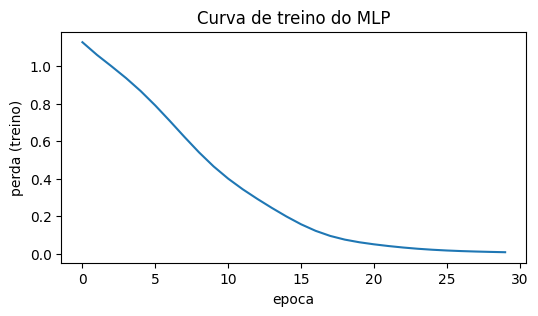

In [5]:
otim = torch.optim.Adam(mlp.parameters(), lr=1e-2)
perda_fn = nn.CrossEntropyLoss()

historico = []
for epoca in range(30):
    otim.zero_grad()
    logits = mlp(X_tr)
    perda = perda_fn(logits, y_tr)
    perda.backward()
    otim.step()
    historico.append(perda.item())

plt.figure(figsize=(6, 3))
plt.plot(historico)
plt.xlabel('epoca'); plt.ylabel('perda (treino)')
plt.title('Curva de treino do MLP')
plt.show()

Para avaliar, desligamos o autograd com `torch.no_grad()` e pegamos a classe de maior
logit com `argmax`.

In [6]:
with torch.no_grad():
    pred = mlp(X_te).argmax(dim=1)

acc = (pred == y_te).float().mean().item()
print(f'acuracia no teste: {acc:.3f}')

acuracia no teste: 1.000


## 2. CNN no MNIST

Em imagens, um MLP ignoraria a estrutura espacial (vizinhanca dos pixels). A camada
convolucional `Conv2d` desliza pequenos filtros pela imagem e detecta padroes locais
(bordas, tracos), reaproveitando os mesmos pesos em toda a imagem. O `MaxPool2d`
reduce a resolucao pela metade, deixando a representacao mais compacta e robusta a
pequenos deslocamentos.

O MNIST tem 60000 imagens de treino e 10000 de teste, cada uma 28x28 em tons de cinza,
com o digito (0 a 9) como rotulo. Na primeira execucao os dados sao baixados para a
pasta `./data`.

## Links legais:

- https://poloclub.github.io/cnn-explainer/
- https://cnn-playground.live/mnist
- https://adamharley.com/nn_vis/cnn/3d.html

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transforma = transforms.ToTensor()  # imagem -> tensor (1, 28, 28) em [0, 1]

treino = datasets.MNIST('./data', train=True,  download=True, transform=transforma)
teste  = datasets.MNIST('./data', train=False, download=True, transform=transforma)

# o DataLoader entrega os dados em lotes (mini-batches)
treino_loader = DataLoader(treino, batch_size=128, shuffle=True)
teste_loader  = DataLoader(teste,  batch_size=256, shuffle=False)

print('treino:', len(treino), '| teste:', len(teste))

100%|████████████████████████████████████████████████████| 9.91M/9.91M [00:03<00:00, 3.30MB/s]
100%|█████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 199kB/s]
100%|█████████████████████████████████████████████████████| 1.65M/1.65M [00:02<00:00, 606kB/s]
100%|████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 12.8MB/s]

treino: 60000 | teste: 10000


Algumas imagens para ver com o que estamos lidando:

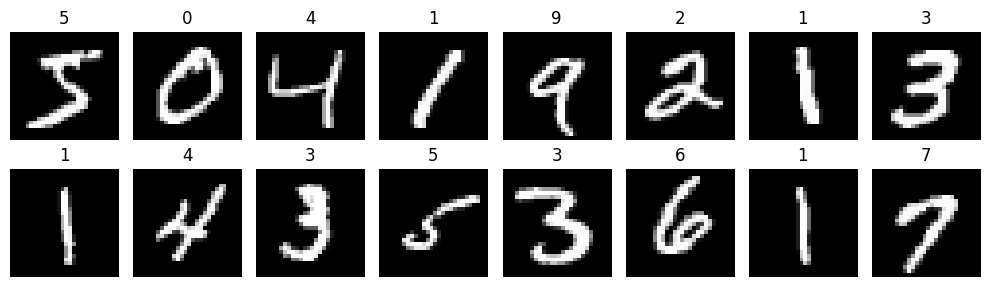

In [10]:
fig, axs = plt.subplots(2, 8, figsize=(10, 3))
for ax, (img, rotulo) in zip(axs.ravel(), treino):
    ax.imshow(img[0], cmap='gray')
    ax.set_title(int(rotulo))
    ax.axis('off')
plt.tight_layout(); plt.show()

A rede alterna convolucao + ReLU + pooling, duas vezes, e termina com camadas
densas para os 10 scores de classe. As camadas novas aqui:

**`nn.Conv2d(1, 8, kernel_size=3, padding=1)`** — convolucao 2D, desliza filtros pela imagem.
- `1`: canais de entrada (1 = tons de cinza; 3 seria RGB).
- `8`: canais de saida = quantos filtros diferentes a camada aprende (8 mapas de padroes).
- `kernel_size=3`: tamanho da janela do filtro, aqui `3x3`. Janela maior enxerga uma regiao maior por vez.
- `padding=1`: bordas de zero ao redor da imagem. Com `kernel 3` e `padding 1` a saida mantem a mesma altura e largura (senao encolheria 2 pixels).
- `stride` (nao usado, padrao `1`): de quantos em quantos pixels a janela anda. `stride=2` reduziria o tamanho pela metade.

**`nn.MaxPool2d(2)`** — reduz a resolucao pegando o maximo em cada janela.
- `2`: tamanho da janela (`2x2`) e tambem o passo, entao altura e largura caem pela metade. E o jeito mais comum de "encolher" a imagem entre as convolucoes.

**`nn.Flatten()`** — sem argumentos: achata tudo (menos a dimensao do lote) num vetor. E a ponte entre a parte convolucional e as camadas `Linear`, que esperam um vetor.

Seguindo as formas: a imagem entra `(1, 28, 28)`; depois de dois `MaxPool2d` vira
`(16, 7, 7)`; por isso o `Flatten` produz `16*7*7 = 784` entradas para a `Linear`.


In [19]:
cnn = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),  nn.ReLU(), nn.MaxPool2d(2),  # -> 8 x 14 x 14
    nn.Conv2d(8, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # -> 16 x 7 x 7
    nn.Flatten(),
    nn.Linear(16 * 7 * 7, 64), nn.ReLU(),
    nn.Linear(64, 10),
).to(device)
cnn

Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=784, out_features=64, bias=True)
  (8): ReLU()
  (9): Linear(in_features=64, out_features=10, bias=True)
)

Agora o treino percorre os lotes do `DataLoader`. Cada lote vai para o `device` antes
do passo. Uma epoca (uma passada por todo o conjunto) ja chega perto de 98% de
acuracia; aumente `n_epocas` para melhorar.

In [20]:
otim = torch.optim.Adam(cnn.parameters(), lr=1e-3)
perda_fn = nn.CrossEntropyLoss()
n_epocas = 10

cnn.train()
for epoca in range(n_epocas):
    for xb, yb in treino_loader:
        xb, yb = xb.to(device), yb.to(device)
        otim.zero_grad()
        perda = perda_fn(cnn(xb), yb)
        perda.backward()
        otim.step()
    print(f'epoca {epoca + 1}: ultima perda do lote = {perda.item():.4f}')

epoca 1: ultima perda do lote = 0.1541
epoca 2: ultima perda do lote = 0.1379
epoca 3: ultima perda do lote = 0.1738
epoca 4: ultima perda do lote = 0.0207
epoca 5: ultima perda do lote = 0.0564
epoca 6: ultima perda do lote = 0.0432
epoca 7: ultima perda do lote = 0.0082
epoca 8: ultima perda do lote = 0.0068
epoca 9: ultima perda do lote = 0.0016
epoca 10: ultima perda do lote = 0.0220


In [21]:
cnn.eval()
acertos, total = 0, 0
with torch.no_grad():
    for xb, yb in teste_loader:
        pred = cnn(xb.to(device)).argmax(dim=1).cpu()
        acertos += (pred == yb).sum().item()
        total += len(yb)

print(f'acuracia no teste: {acertos / total:.3f}')

acuracia no teste: 0.988


Vendo as previsoes em alguns exemplos do teste (titulo = previsto / verdadeiro):

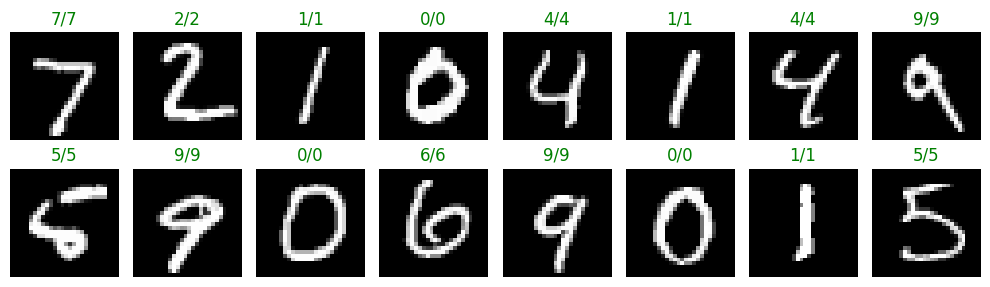

In [22]:
xb, yb = next(iter(teste_loader))
with torch.no_grad():
    pred = cnn(xb.to(device)).argmax(dim=1).cpu()

fig, axs = plt.subplots(2, 8, figsize=(10, 3))
for ax, img, p, v in zip(axs.ravel(), xb, pred, yb):
    ax.imshow(img[0], cmap='gray')
    cor = 'green' if p == v else 'red'
    ax.set_title(f'{int(p)}/{int(v)}', color=cor)
    ax.axis('off')
plt.tight_layout(); plt.show()

## 3. Autoencoder no MNIST

Ate aqui usamos os rotulos (aprendizado supervisionado). O autoencoder e *nao
supervisionado*: ele aprende a reconstruir a propria entrada. Tem duas partes:

- **encoder**: comprime a imagem (784 pixels) num vetor pequeno, o *codigo latente*;
- **decoder**: tenta reconstruir a imagem a partir desse codigo.

O gargalo (aqui, 16 numeros) forca a rede a guardar so o essencial. A perda e o erro
quadratico medio entre a imagem original e a reconstruida. Note que o alvo e a propria
entrada, nao o rotulo.

A camada nova aqui e a ativacao da saida do decoder:

**`nn.Sigmoid()`** — sem pesos nem argumentos. Aplica `1 / (1 + e^-x)` ponto a ponto,
espremendo qualquer numero para o intervalo `[0, 1]`. Usamos na saida porque os pixels
do MNIST tambem vivem em `[0, 1]`, entao a reconstrucao fica na mesma escala da imagem.


In [27]:
encoder = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128), nn.ReLU(),
    nn.Linear(128, 16),
)

decoder = nn.Sequential(
    nn.Linear(16, 128), nn.ReLU(),
    nn.Linear(128, 784), nn.Sigmoid(),  # pixels em [0, 1]
)

autoencoder = nn.Sequential(encoder, decoder).to(device)
autoencoder

Sequential(
  (0): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=16, bias=True)
  )
  (1): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

In [28]:
otim = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
perda_fn = nn.MSELoss()
n_epocas = 10

autoencoder.train()
for epoca in range(n_epocas):
    for xb, _ in treino_loader:        # o rotulo nao e usado
        xb = xb.to(device)
        alvo = xb.view(xb.size(0), -1)  # achata para comparar com a saida
        saida = autoencoder(xb)
        otim.zero_grad()
        perda = perda_fn(saida, alvo)
        perda.backward()
        otim.step()
    print(f'epoca {epoca + 1}: perda = {perda.item():.4f}')

epoca 1: perda = 0.0275
epoca 2: perda = 0.0189
epoca 3: perda = 0.0192
epoca 4: perda = 0.0164
epoca 5: perda = 0.0161
epoca 6: perda = 0.0138
epoca 7: perda = 0.0144
epoca 8: perda = 0.0145
epoca 9: perda = 0.0146
epoca 10: perda = 0.0133


Comparando originais (linha de cima) com as reconstrucoes (linha de baixo). Mesmo
passando por um gargalo de 16 numeros, a rede recupera o digito.

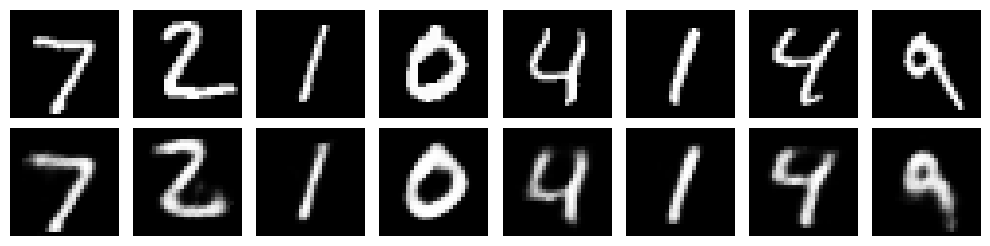

In [29]:
xb, _ = next(iter(teste_loader))
autoencoder.eval()
with torch.no_grad():
    rec = autoencoder(xb.to(device)).cpu().view(-1, 28, 28)

fig, axs = plt.subplots(2, 8, figsize=(10, 2.6))
for i in range(8):
    axs[0, i].imshow(xb[i, 0], cmap='gray');     axs[0, i].axis('off')
    axs[1, i].imshow(rec[i],   cmap='gray');     axs[1, i].axis('off')
axs[0, 0].set_ylabel('original');  axs[1, 0].set_ylabel('reconstruida')
plt.tight_layout(); plt.show()

O codigo latente tambem organiza os dados. Projetando os 16 numeros em 2D com PCA e
colorindo pelos rotulos (que o autoencoder nunca viu), digitos parecidos caem perto:
a rede capturou estrutura util sem supervisao.

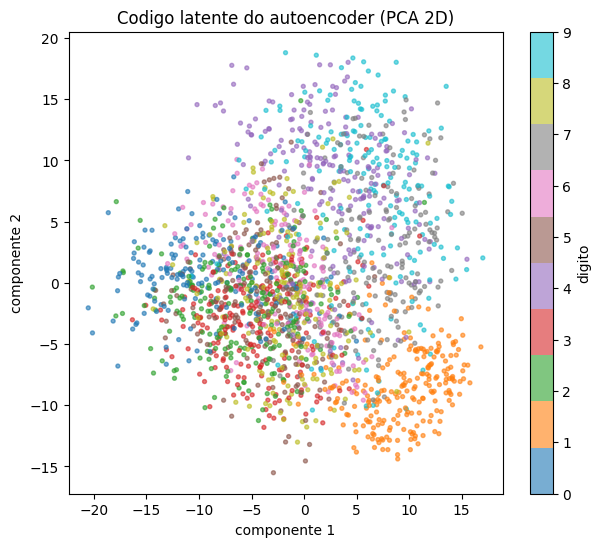

In [31]:
from sklearn.decomposition import PCA

xb, yb = next(iter(DataLoader(teste, batch_size=2000, shuffle=False)))
with torch.no_grad():
    codigos = encoder(xb.to(device)).cpu().numpy()

proj = PCA(n_components=2).fit_transform(codigos)

plt.figure(figsize=(7, 6))
sc = plt.scatter(proj[:, 0], proj[:, 1], c=yb.numpy(), cmap='tab10', s=8, alpha=0.6)
plt.colorbar(sc, label='digito')
plt.title('Codigo latente do autoencoder (PCA 2D)')
plt.xlabel('componente 1'); plt.ylabel('componente 2')
plt.show()